In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

In [2]:
try:
    recommendation_df = feature_df.copy()
    print("Using feature-engineered data from memory")

except NameError:
    recommendation_df = pd.read_excel(
        "clinical_feature_engineered_data.xlsx",
        sheet_name="Feature_Engineered_Data"
    )
    print("Using saved feature-engineered dataset")

print("Dataset shape:", recommendation_df.shape)
recommendation_df.head()

Using saved feature-engineered dataset
Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [3]:
recommendation_df.columns = (
    recommendation_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(recommendation_df.columns.tolist())

['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [4]:
target_column = "historical_medication_class"

patient_features = [
    "age_years",
    "sex",
    "condition",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm",
    "recorded_allergy",
    "family_history",
    "adherence_level",
    "pulse_pressure_mmhg",
    "allergy_recorded_flag",
    "family_history_flag",
    "adherence_score"
]

patient_features = [
    column for column in patient_features
    if column in recommendation_df.columns
]

if target_column not in recommendation_df.columns:
    raise ValueError(
        f"Target column '{target_column}' is missing."
    )

X = recommendation_df[patient_features].copy()
y = recommendation_df[target_column].copy()

print("Features:", X.shape)
print("Target:", y.shape)
print("Target classes:", y.nunique())

Features: (500, 15)
Target: (500,)
Target classes: 12


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 400
Testing records: 100


In [6]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'pulse_pressure_mmhg', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score']

Categorical features:
['sex', 'condition', 'recorded_allergy', 'family_history', 'adherence_level']


In [7]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            encoder
        )
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

base_recommendation_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

base_recommendation_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
base_recommendation_model.fit(
    X_train,
    y_train
)

model_classes = base_recommendation_model.named_steps[
    "classifier"
].classes_

print("Model trained successfully.")
print("Classes:", model_classes)

Model trained successfully.
Classes: ['Acid-suppression class A' 'Acid-suppression class B'
 'Antidiabetic class A' 'Antidiabetic class B' 'Antihistamine class A'
 'Antihistamine class B' 'Antihypertensive class A'
 'Antihypertensive class B' 'Bronchodilator class'
 'Controller inhaler class' 'Lipid-lowering class A'
 'Lipid-lowering class B']


In [10]:
training_relationships = recommendation_df.loc[
    X_train.index,
    ["condition", target_column]
].copy()

condition_class_prior = pd.crosstab(
    training_relationships["condition"],
    training_relationships[target_column],
    normalize="index"
)

condition_class_prior = condition_class_prior.reindex(
    columns=model_classes,
    fill_value=0
)

condition_class_prior.round(3)

historical_medication_class,Acid-suppression class A,Acid-suppression class B,Antidiabetic class A,Antidiabetic class B,Antihistamine class A,Antihistamine class B,Antihypertensive class A,Antihypertensive class B,Bronchodilator class,Controller inhaler class,Lipid-lowering class A,Lipid-lowering class B
condition,,,,,,,,,,,,
Acid Reflux,0.548,0.452,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Asthma,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.439,0.561,0.000,0.000
High Cholesterol,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.557,0.443
Hypertension,0.000,0.000,0.000,0.000,0.000,0.000,0.507,0.493,0.000,0.000,0.000,0.000
Seasonal Allergy,0.000,0.000,0.000,0.000,0.568,0.432,0.000,0.000,0.000,0.000,0.000,0.000
Type 2 Diabetes,0.000,0.000,0.514,0.486,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [11]:
base_probabilities = (
    base_recommendation_model.predict_proba(
        X_test
    )
)

print(
    "Probability matrix shape:",
    base_probabilities.shape
)

Probability matrix shape: (100, 12)


In [12]:
condition_probabilities = []

uniform_probability = np.ones(
    len(model_classes)
) / len(model_classes)

for condition in X_test["condition"]:

    if condition in condition_class_prior.index:
        prior = condition_class_prior.loc[
            condition,
            model_classes
        ].values.astype(float)

    else:
        prior = uniform_probability.copy()

    condition_probabilities.append(prior)

condition_probabilities = np.array(
    condition_probabilities
)

print(
    "Condition probability shape:",
    condition_probabilities.shape
)

Condition probability shape: (100, 12)


In [13]:
model_weight = 0.80
condition_history_weight = 0.20

hybrid_scores = (
    model_weight * base_probabilities +
    condition_history_weight * condition_probabilities
)
hybrid_scores = (
    hybrid_scores /
    hybrid_scores.sum(axis=1, keepdims=True)
)

print("Hybrid scores created successfully.")

Hybrid scores created successfully.


In [14]:
top_n = 3

top_indices = np.argsort(
    hybrid_scores,
    axis=1
)[:, -top_n:][:, ::-1]

recommendation_results = pd.DataFrame({
    "patient_id": recommendation_df.loc[
        X_test.index,
        "patient_id"
    ].values,
    "condition": X_test["condition"].values,
    "recorded_allergy":
        X_test["recorded_allergy"].values,
    "actual_historical_class": y_test.values
})

for rank in range(top_n):

    recommendation_results[
        f"rank_{rank + 1}_class"
    ] = model_classes[
        top_indices[:, rank]
    ]

    recommendation_results[
        f"rank_{rank + 1}_score"
    ] = hybrid_scores[
        np.arange(len(hybrid_scores)),
        top_indices[:, rank]
    ].round(4)

recommendation_results.head(10)

,patient_id,condition,recorded_allergy,actual_historical_class,rank_1_class,rank_1_score,rank_2_class,rank_2_score,rank_3_class,rank_3_score
0,SYN-0049,Asthma,None recorded,Controller inhaler class,Controller inhaler class,0.7134,Bronchodilator class,0.2502,Antihistamine class B,0.0085
1,SYN-0135,Type 2 Diabetes,None recorded,Antidiabetic class A,Antidiabetic class B,0.5832,Antidiabetic class A,0.4110,Bronchodilator class,0.0015
2,SYN-0094,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5792,Lipid-lowering class B,0.4040,Antihypertensive class A,0.0043
3,SYN-0131,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5383,Lipid-lowering class B,0.4519,Antihistamine class B,0.0021
4,SYN-0467,Seasonal Allergy,None recorded,Antihistamine class B,Antihistamine class A,0.5194,Antihistamine class B,0.3572,Lipid-lowering class A,0.0326
5,SYN-0430,Asthma,None recorded,Bronchodilator class,Bronchodilator class,0.6303,Controller inhaler class,0.2995,Acid-suppression class B,0.0178
6,SYN-0241,Hypertension,Sulfonamide,Antihypertensive class B,Antihypertensive class B,0.7335,Antihypertensive class A,0.2646,Acid-suppression class A,0.0007
7,SYN-0447,Type 2 Diabetes,None recorded,Antidiabetic class B,Antidiabetic class B,0.6453,Antidiabetic class A,0.3505,Bronchodilator class,0.0020
8,SYN-0252,Seasonal Allergy,Latex,Antihistamine class B,Antihistamine class A,0.4484,Antihistamine class B,0.3944,Lipid-lowering class B,0.0428
9,SYN-0011,Hypertension,Latex,Antihypertensive class A,Antihypertensive class B,0.6404,Antihypertensive class A,0.3045,Antihistamine class A,0.0145


In [15]:
recommendation_results[
    "safety_review_required"
] = np.where(
    recommendation_results[
        "recorded_allergy"
    ].str.lower().eq("none recorded"),
    "Standard review required",
    "Allergy information requires professional review"
)

recommendation_results[
    "system_notice"
] = (
    "Synthetic historical class ranking; "
    "not a prescription"
)

recommendation_results.head()

,patient_id,condition,recorded_allergy,actual_historical_class,rank_1_class,rank_1_score,rank_2_class,rank_2_score,rank_3_class,rank_3_score,safety_review_required,system_notice
0,SYN-0049,Asthma,None recorded,Controller inhaler class,Controller inhaler class,0.7134,Bronchodilator class,0.2502,Antihistamine class B,0.0085,Standard review required,Synthetic historical class ranking; not a pres...
1,SYN-0135,Type 2 Diabetes,None recorded,Antidiabetic class A,Antidiabetic class B,0.5832,Antidiabetic class A,0.4110,Bronchodilator class,0.0015,Standard review required,Synthetic historical class ranking; not a pres...
2,SYN-0094,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5792,Lipid-lowering class B,0.4040,Antihypertensive class A,0.0043,Standard review required,Synthetic historical class ranking; not a pres...
3,SYN-0131,High Cholesterol,None recorded,Lipid-lowering class A,Lipid-lowering class A,0.5383,Lipid-lowering class B,0.4519,Antihistamine class B,0.0021,Standard review required,Synthetic historical class ranking; not a pres...
4,SYN-0467,Seasonal Allergy,None recorded,Antihistamine class B,Antihistamine class A,0.5194,Antihistamine class B,0.3572,Lipid-lowering class A,0.0326,Standard review required,Synthetic historical class ranking; not a pres...


In [16]:
hybrid_predictions = model_classes[
    np.argmax(hybrid_scores, axis=1)
]

accuracy = accuracy_score(
    y_test,
    hybrid_predictions
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    hybrid_predictions
)

macro_f1 = f1_score(
    y_test,
    hybrid_predictions,
    average="macro"
)

top_2_accuracy = top_k_accuracy_score(
    y_test,
    hybrid_scores,
    k=2,
    labels=model_classes
)

top_3_accuracy = top_k_accuracy_score(
    y_test,
    hybrid_scores,
    k=3,
    labels=model_classes
)

evaluation_results = pd.DataFrame({
    "metric": [
        "Top-1 Accuracy",
        "Balanced Accuracy",
        "Macro F1-score",
        "Top-2 Accuracy",
        "Top-3 Accuracy"
    ],
    "score": [
        accuracy,
        balanced_accuracy,
        macro_f1,
        top_2_accuracy,
        top_3_accuracy
    ]
})

evaluation_results["score"] = (
    evaluation_results["score"].round(4)
)

evaluation_results

,metric,score
0,Top-1 Accuracy,0.4400
1,Balanced Accuracy,0.4382
2,Macro F1-score,0.4330
3,Top-2 Accuracy,1.0000
4,Top-3 Accuracy,1.0000


In [17]:
classification_results = pd.DataFrame(
    classification_report(
        y_test,
        hybrid_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose()

classification_results.round(4)

,precision,recall,f1-score,support
Acid-suppression class A,0.5714,0.5000,0.5333,8.00
Acid-suppression class B,0.5000,0.5714,0.5333,7.00
Antidiabetic class A,0.5000,0.4444,0.4706,9.00
Antidiabetic class B,0.4444,0.5000,0.4706,8.00
Antihistamine class A,0.4444,0.4000,0.4211,10.00
Antihistamine class B,0.3333,0.3750,0.3529,8.00
Antihypertensive class A,0.3333,0.2222,0.2667,9.00
Antihypertensive class B,0.4167,0.5556,0.4762,9.00
Bronchodilator class,0.5000,0.5714,0.5333,7.00
Controller inhaler class,0.6667,0.6000,0.6316,10.00


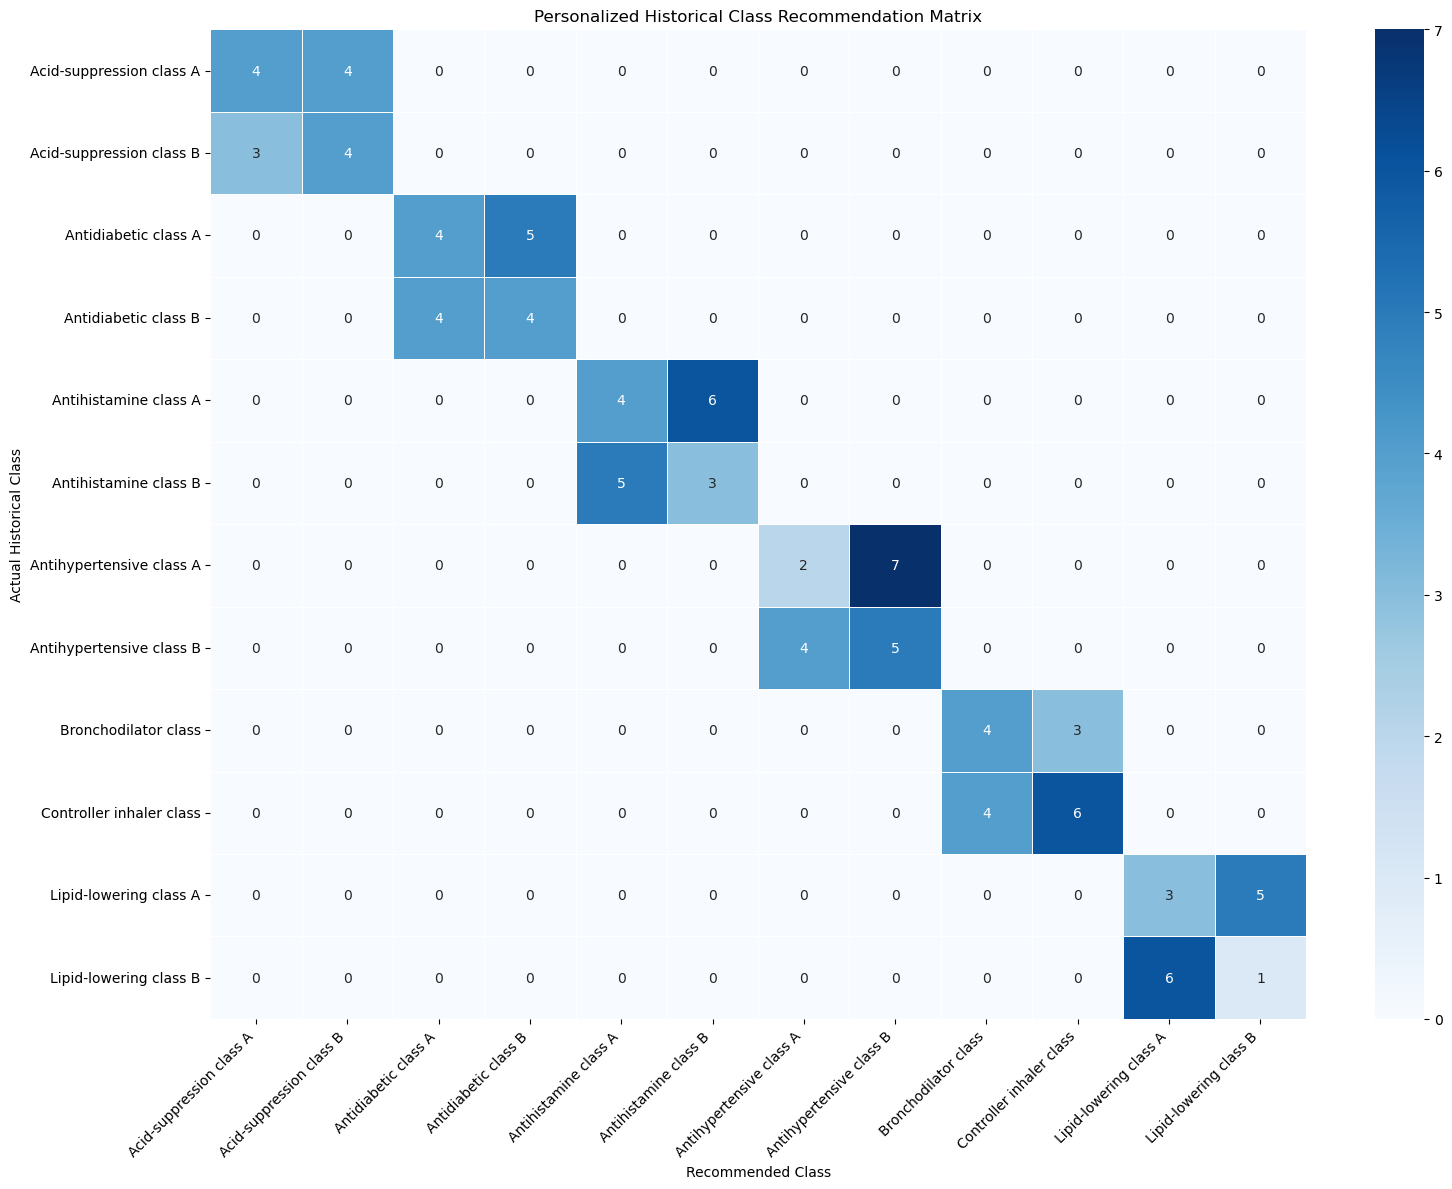

In [18]:
confusion = confusion_matrix(
    y_test,
    hybrid_predictions,
    labels=model_classes
)

confusion_df = pd.DataFrame(
    confusion,
    index=model_classes,
    columns=model_classes
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Personalized Historical Class Recommendation Matrix")
plt.xlabel("Recommended Class")
plt.ylabel("Actual Historical Class")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [19]:
def generate_personalized_recommendations(
    patient_data,
    top_n=3
):
    input_profile = {
        column: np.nan
        for column in patient_features
    }

    input_profile.update(patient_data)

    input_df = pd.DataFrame(
        [input_profile]
    )[patient_features]

    model_scores = (
        base_recommendation_model.predict_proba(
            input_df
        )[0]
    )

    patient_condition = input_df.iloc[0][
        "condition"
    ]

    if patient_condition in condition_class_prior.index:

        condition_scores = condition_class_prior.loc[
            patient_condition,
            model_classes
        ].values.astype(float)

    else:
        condition_scores = np.ones(
            len(model_classes)
        ) / len(model_classes)

    final_scores = (
        model_weight * model_scores +
        condition_history_weight * condition_scores
    )

    final_scores = final_scores / final_scores.sum()

    top_n = min(top_n, len(model_classes))

    top_positions = np.argsort(
        final_scores
    )[::-1][:top_n]

    recommendations = pd.DataFrame({
        "rank": range(1, top_n + 1),
        "historical_medication_class":
            model_classes[top_positions],
        "recommendation_score":
            final_scores[top_positions].round(4)
    })

    recorded_allergy = str(
        input_df.iloc[0]["recorded_allergy"]
    )

    if recorded_allergy.lower() == "none recorded":
        safety_message = (
            "No allergy recorded in synthetic input; "
            "professional safety review is still required."
        )
    else:
        safety_message = (
            "An allergy is recorded. This dataset cannot "
            "verify contraindications; professional review "
            "is required."
        )

    recommendations[
        "safety_notice"
    ] = safety_message

    recommendations[
        "educational_notice"
    ] = (
        "Synthetic historical association; "
        "not a prescription."
    )

    return recommendations

In [20]:
sample_patient = X_test.iloc[0].to_dict()

print("Synthetic input profile:")
display(X_test.iloc[[0]])

generate_personalized_recommendations(
    patient_data=sample_patient,
    top_n=3
)

Synthetic input profile:


,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,family_history,adherence_level,pulse_pressure_mmhg,allergy_recorded_flag,family_history_flag,adherence_score
48,26,Male,Asthma,83,108,75,175,64,None recorded,No,Medium,33,0,0,1


,rank,historical_medication_class,recommendation_score,safety_notice,educational_notice
0,1,Controller inhaler class,0.7134,No allergy recorded in synthetic input; profes...,Synthetic historical association; not a prescr...
1,2,Bronchodilator class,0.2502,No allergy recorded in synthetic input; profes...,Synthetic historical association; not a prescr...
2,3,Antihistamine class B,0.0085,No allergy recorded in synthetic input; profes...,Synthetic historical association; not a prescr...


In [21]:
output_file = "personalized_recommendation_results.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    recommendation_results.to_excel(
        writer,
        sheet_name="Recommendations",
        index=False
    )

    evaluation_results.to_excel(
        writer,
        sheet_name="Evaluation",
        index=False
    )

    classification_results.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    condition_class_prior.to_excel(
        writer,
        sheet_name="Condition_Class_Prior"
    )

print("Saved:", output_file)

Saved: personalized_recommendation_results.xlsx


In [22]:
recommendation_system = {
    "model": base_recommendation_model,
    "patient_features": patient_features,
    "model_classes": model_classes,
    "condition_class_prior": condition_class_prior,
    "model_weight": model_weight,
    "condition_history_weight":
        condition_history_weight
}

joblib.dump(
    recommendation_system,
    "personalized_recommendation_system.pkl"
)

print("Recommendation system saved successfully.")

Recommendation system saved successfully.
